In [6]:
import wandb
import matplotlib.pyplot as plt
import numpy as np

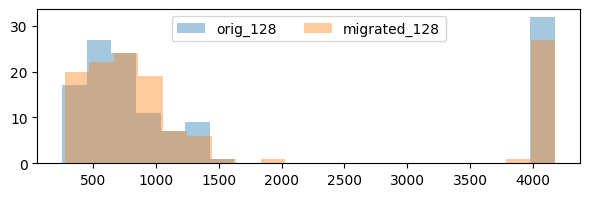

In [20]:
plt.figure(figsize=(7, 2))

with open("../../experiments/rollout_results.csv") as f:
    data = f.read().split("\n")

for line in data[1:]:
    if len(line) <= 1:
        continue
    if '128,"' not in line:
        continue
    line = line.split("[")[1]
    line = line.split("]")[0]
    lens = [int(i) for i in line.split(", ")]
    plt.hist(lens, label='orig_128', alpha=0.4, bins=20)

migrated_lens_128 = [298, 274, 294, 272, 320, 319, 348, 358, 358, 370, 367, 370, 397, 415, 408, 426, 418, 420, 411, 443, 510, 475, 504, 491, 525, 539,
                     551, 567, 580, 581, 590, 590, 585, 597, 603, 626, 647, 632, 652, 625, 644, 673, 703, 654, 687, 689, 690, 709, 721, 710, 742, 727,
                     764, 733, 742, 780, 764, 768, 785, 785, 803, 805, 807, 849, 823, 839, 881, 891, 897, 899, 935, 929, 941, 961, 954, 943, 966, 964,
                     972, 983, 987, 1013, 1020, 1062, 1042, 1051, 1092, 1120, 1128, 1143, 1241, 1187, 1278, 1251, 1365, 1282, 1436, 1398, 1471, 1850,
                     3931, 4097, 4078, 4075, 4126, 4057, 4113, 4090, 4116, 4095, 4127, 4111, 4148, 4065, 4107, 4125, 4106, 4110, 4111, 4126, 4140, 4125,
                     4164, 4135, 4178, 4159, 4145, 4115]
plt.hist(migrated_lens_128, label='migrated_128', alpha=0.4, bins=20)
plt.legend(loc='upper center', ncols=2)

In [ ]:
def plot(key, title):
    api = wandb.Api()
    run = api.run(f"madoka-hong-kong-university-of-science-and-technology/roll_examples/runs/{key}")
    history = run.history(stream="systemMetrics")

    ngpus = 8
    plt.figure(figsize=(12, 2.5))
    gmem_allocated = [[] for _ in range(ngpus)]
    print(len(history))
    for step in range(len(history)):
        for gid in range(ngpus):
            if f'system.gpu.{gid}.memoryAllocated' in history[step]:
                gmem_allocated[gid].append(history[step][f'system.gpu.{gid}.memoryAllocated'])
            # else:
            #     gmem_allocated[gid].append(0)

    for gid in range(ngpus):
        gmem_allocated[gid] = np.array(gmem_allocated[gid])
        plt.plot(gmem_allocated[gid], label=f"{gid}")
    plt.legend(ncols=8)
    plt.title(title)

    # print(len(gmem_allocated[0]))
    gen_util = len(gmem_allocated[0][np.where(gmem_allocated[0] > 10)]) / len(gmem_allocated[0])
    train_util = len(gmem_allocated[7][np.where(gmem_allocated[7] > 10)]) / len(gmem_allocated[7])
    print(f"Gen util: {gen_util}, Train util: {train_util}")

In [ ]:
plot("htl8kcje", "Single Tenant")

In [ ]:
plot("4sddtlf8", "Multi Tenant (A)")

In [ ]:
plot("9hmp3d4z", "Multi Tenant (B)")

In [ ]:
plot("mk0yt45n", "3 Tenant (A)")

In [ ]:
plot("uu07nofv", "3 Tenant (B)")

In [ ]:
plot("owft1alp", "3 Tenant (C)")